# Unitree G1 (MuJoCo) — ZMP/CoM Planning + Kinematic Walking via Constrained DLS IK

**Goal:** footsteps → ZMP reference → Drake `ZmpPlanner` → nominal CoM → constrained velocity IK → `qpos` trajectory → MuJoCo viewer.

> This notebook generates a **kinematic** walking motion (IK playback).  
> It is meant for teaching the planning/IK pipeline, not for dynamic torque control.


## 0. Setup


In [1]:
# Installing packages inside a notebook
%pip install mujoco drake

import os
import time
import numpy as np
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

import mujoco
import mujoco.viewer

# Drake imports
try:
    from pydrake.trajectories import PiecewisePolynomial
    from pydrake.planning import ZmpPlanner
except Exception as e:
    raise ImportError(
        "Could not import pydrake. "
        "Make sure you installed the correct package via `pip install drake` "
        "and that your OS/Python combo is supported by Drake wheels."
    ) from e

np.set_printoptions(precision=4, suppress=True)


  Using cached matplotlib-3.10.8-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached pydot-4.0.1-py3-none-any.whl.metadata (11 kB)
  Using cached pyyaml-6.0.3-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached mosek-11.1.2-cp39-abi3-manylinux2014_x86_64.whl.metadata (697 bytes)
  Using cached contourpy-1.3.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 MB 343.3 kB/s  0:01:48m0:00:0300:04
Using cached mosek-11.1.2-cp39-abi3-manylinux2014_x86_64.whl (15.4 MB)
Using cached matplotlib-3.10.8-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached contourpy-1.3.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (355 kB)
Using cached cycler-0.

## 1. Load the G1 model (and patch: sole sites + floor)

We use the uploaded `g1_29dof.xml`.  
Because it does not include `left_sole/right_sole` sites (needed for clean foot tracking), we patch the MJCF:

- add `left_sole` / `right_sole` sites under `left_ankle_roll_link` / `right_ankle_roll_link`
- add a floor plane at `z=0` (if none exists)

We also **auto-settle** the floating base height so the soles are exactly on the floor at the start.


In [2]:
# -------------------------
# Paths and parameters
# -------------------------
G1_XML_IN = "../01-KG-04-HumanoidBasics/unitree_g1/g1_29dof_scene.xml"   # uploaded file
DEBUG_PRINT = True

# Walking plan
STEP_LENGTH = 0.30
N_STEP_PAIRS = 4
SWING_HEIGHT = 0.07

# Timing
double_support_duration = 1
single_support_duration = 1

# IK / playback
VIEW_FPS = 60.0
DT = 1.0 / VIEW_FPS
IK_ITERS_PER_FRAME = 12


In [3]:
# -------------------------
# Joint-name configuration (matches the uploaded G1 MJCF)
# -------------------------
BASE_JOINT = "floating_base_joint"

LEG_JOINTS = [
    "left_hip_pitch_joint", "left_hip_roll_joint", "left_hip_yaw_joint",
    "left_knee_joint", "left_ankle_pitch_joint", "left_ankle_roll_joint",
    "right_hip_pitch_joint", "right_hip_roll_joint", "right_hip_yaw_joint",
    "right_knee_joint", "right_ankle_pitch_joint", "right_ankle_roll_joint",
]

# Freeze all upper-body joints (leg-only demo)
UPPER_BODY_JOINTS_TO_FREEZE = [
    "waist_yaw_joint", "waist_roll_joint", "waist_pitch_joint",
    "left_shoulder_pitch_joint", "left_shoulder_roll_joint", "left_shoulder_yaw_joint",
    "left_elbow_joint", "left_wrist_roll_joint", "left_wrist_pitch_joint", "left_wrist_yaw_joint",
    "right_shoulder_pitch_joint", "right_shoulder_roll_joint", "right_shoulder_yaw_joint",
    "right_elbow_joint", "right_wrist_roll_joint", "right_wrist_pitch_joint", "right_wrist_yaw_joint",
]


In [4]:
# -------------------------
# MJCF patching
# -------------------------
def add_sole_sites_and_floor(xml_in: str) -> str:
    """Create patched MJCF next to `xml_in` and return its path."""
    tree = ET.parse(xml_in)
    root = tree.getroot()

    worldbody = root.find("worldbody")
    if worldbody is None:
        raise RuntimeError("MJCF has no <worldbody>")

    # Add a floor plane if none exists
    has_plane = any((g.get("type") == "plane") for g in worldbody.findall("geom"))
    if not has_plane:
        ET.SubElement(worldbody, "geom", {
            "name": "floor",
            "type": "plane",
            "pos": "0 0 0",
            "size": "5 5 0.1",
            "rgba": "0.9 0.9 0.9 1",
            "contype": "1",
            "conaffinity": "1",
        })

    # Find foot bodies
    def find_body(name: str):
        for b in worldbody.iter("body"):
            if b.get("name") == name:
                return b
        return None

    lb = find_body("left_ankle_roll_link")
    rb = find_body("right_ankle_roll_link")
    if lb is None or rb is None:
        raise RuntimeError("Could not find left/right ankle roll link bodies")

    # Sole site position in ankle-roll body frame
    sole_pos = "0.035 0 -0.035"   # center of 4 contact spheres, at their bottom

    def upsert_site(body_elem, site_name: str):
        for s in body_elem.findall("site"):
            if s.get("name") == site_name:
                s.set("pos", sole_pos)
                s.set("size", "0.012")
                s.set("rgba", "1 0 0 0.2")
                return
        ET.SubElement(body_elem, "site", {
            "name": site_name,
            "pos": sole_pos,
            "size": "0.012",
            "rgba": "1 0 0 0.2",
        })

    upsert_site(lb, "left_sole")
    upsert_site(rb, "right_sole")

    out_path = os.path.join(os.path.dirname(xml_in), "g1_29dof_with_sole_sites_floor.xml")
    tree.write(out_path, encoding="utf-8")
    return out_path


# Load model
G1_XML = add_sole_sites_and_floor(G1_XML_IN)
model = mujoco.MjModel.from_xml_path(G1_XML)
data  = mujoco.MjData(model)
mujoco.mj_forward(model, data)

lsole_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, "left_sole")
rsole_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, "right_sole")
assert lsole_id >= 0 and rsole_id >= 0

# Floor z (we created the plane at z=0)
floor_z = 0.0

# Auto-settle: shift floating base so soles touch the floor
base_jid = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, BASE_JOINT)
base_qadr = int(model.jnt_qposadr[base_jid])  # free joint => [x,y,z,qw,qx,qy,qz]
pL0 = data.site_xpos[lsole_id].copy()
pR0 = data.site_xpos[rsole_id].copy()
avg_sole_z = 0.5 * (float(pL0[2]) + float(pR0[2]))
dz = float(floor_z - avg_sole_z)

if abs(dz) > 1e-6:
    data.qpos[base_qadr + 2] += dz
    mujoco.mj_forward(model, data)

if DEBUG_PRINT:
    print("[DEBUG] settled dz =", dz)
    print("[DEBUG] left_sole.z  =", data.site_xpos[lsole_id])
    print("[DEBUG] right_sole.z =", data.site_xpos[rsole_id])


[DEBUG] settled dz = 0.004863752422174749
[DEBUG] left_sole.z  = [ 0.035   0.1185 -0.    ]
[DEBUG] right_sole.z = [ 0.035  -0.1185 -0.    ]


## 2. Footsteps, DS/SS schedule, time grid

- **DS** (double support): both feet fixed
- **SS** (single support): one stance foot fixed, other swings to next target


In [5]:
def make_footsteps_from_initial(left0_xy, right0_xy, step_length=0.30, n_step_pairs=4):
    footsteps = [left0_xy.copy(), right0_xy.copy()]
    x_mid = 0.5 * (left0_xy[0] + right0_xy[0])
    yL, yR = left0_xy[1], right0_xy[1]
    for _ in range(n_step_pairs):
        x_mid += step_length
        footsteps.append(np.array([x_mid, yL], float))
        x_mid += step_length
        footsteps.append(np.array([x_mid, yR], float))
    return np.vstack(footsteps)

left0_xy  = data.site_xpos[lsole_id][:2].copy()
right0_xy = data.site_xpos[rsole_id][:2].copy()
footsteps = make_footsteps_from_initial(left0_xy, right0_xy, STEP_LENGTH, N_STEP_PAIRS)

ds = float(double_support_duration)
ss = float(single_support_duration)

# Total duration: initial DS + (SS+DS) for each new landing after the initial stance
n_targets = len(footsteps) - 2
T_total = ds + n_targets * (ss + ds)

ts = np.arange(0.0, T_total + 1e-9, DT)

print("footsteps:", footsteps.shape, "| T_total:", T_total, "s | frames:", len(ts))


footsteps: (10, 2) | T_total: 17.0 s | frames: 1021


## 3. ZMP reference and Drake `ZmpPlanner` → nominal CoM

### LIPM intuition (2D)
Under the linear inverted pendulum assumption (approximately constant CoM height `h`):
\[
z = x - \frac{h}{g}\ddot{x}
\]
Given a desired ZMP trajectory `z(t)`, Drake computes a nominal CoM trajectory `x(t)` consistent with the LIPM.

### Our ZMP reference (teaching simplification)
- DS: linearly move ZMP between the midpoints of the supporting feet
- SS: hold ZMP at the stance foot center


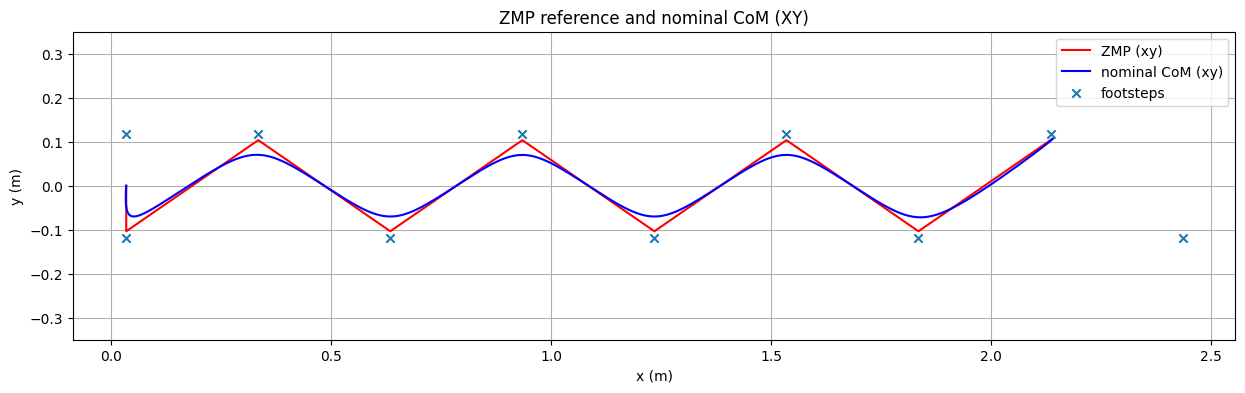

In [6]:
def phase_and_progress(t, ds, ss, n_footsteps):
    if t < ds:
        return "DS", 2, True, 0.0  # first swing left

    t_rem = t - ds
    step_i = 2
    while step_i < n_footsteps:
        if t_rem < ss:
            swing_left = (step_i % 2 == 0)
            s = float(np.clip(t_rem / ss, 0.0, 1.0))
            return "SS", step_i, swing_left, s
        t_rem -= ss

        if t_rem < ds:
            return "DS", step_i, (step_i % 2 == 0), 0.0
        t_rem -= ds
        step_i += 1

    return "END", n_footsteps, False, 1.0


def generate_desired_zmp_traj(footsteps_xy, ds, ss):
    """Piecewise-linear ZMP in 2D."""
    times = [0.0]
    knots = []

    L = footsteps_xy[0].copy()
    R = footsteps_xy[1].copy()
    center = 0.5 * (L + R)
    knots.append(center.reshape(2,1))

    t = 0.0
    # initial DS (stay at center)
    t += ds
    times.append(t); knots.append(center.reshape(2,1))

    for step_i in range(2, len(footsteps_xy)):
        swing_left = (step_i % 2 == 0)

        # SS: ZMP at stance foot
        stance = R if swing_left else L
        t += ss
        times.append(t); knots.append(stance.reshape(2,1))

        # landing updates swing foot
        if swing_left:
            L = footsteps_xy[step_i].copy()
        else:
            R = footsteps_xy[step_i].copy()

        # DS: shift to new center
        center = 0.5 * (L + R)
        t += ds
        times.append(t); knots.append(center.reshape(2,1))

    return PiecewisePolynomial.FirstOrderHold(times, knots)


import numpy as np
from pydrake.trajectories import PiecewisePolynomial

def _zmp_inside_toward_midline(stance_xy, margin_y=0.015):
    """
    Move ZMP a bit toward y=0 to stay inside the stance foot.
    For left foot (y>0): subtract margin. For right foot (y<0): add margin.
    """
    x, y = float(stance_xy[0]), float(stance_xy[1])
    if abs(y) < 1e-9:
        y_in = y
    else:
        y_in = y - np.sign(y) * margin_y
    return np.array([x, y_in], dtype=float)

def generate_desired_zmp_traj(footsteps_xy, ds, ss, margin_y=0.015):
    """
    ZMP reference consistent with desired_feet_pos()/phase_and_progress():
      - Initial DS: center -> first stance foot (right, since first swing is left)
      - SS: hold inside stance foot
      - DS: shift to next stance foot (the foot that just landed)
    """
    footsteps_xy = [np.asarray(p).reshape(2) for p in footsteps_xy]
    assert len(footsteps_xy) >= 2, "Need at least initial L and R footsteps."

    L = footsteps_xy[0].copy()
    R = footsteps_xy[1].copy()

    times = [0.0]
    knots = []

    # Start at mid-foot center
    center = 0.5 * (L + R)
    knots.append(center.reshape(2, 1))

    t = 0.0

    # First swing is LEFT (per your phase_and_progress), so first stance is RIGHT.
    zmp_to = _zmp_inside_toward_midline(R, margin_y)
    t += ds
    times.append(t); knots.append(zmp_to.reshape(2, 1))

    # Now iterate landings from i=2..end-1
    for i in range(2, len(footsteps_xy)):
        swing_left = (i % 2 == 0)   # i even => landing is LEFT => swing was LEFT => stance is RIGHT during SS
        stance_xy = R if swing_left else L
        zmp_ss = _zmp_inside_toward_midline(stance_xy, margin_y)

        # SS: keep ZMP in stance foot
        t += ss
        times.append(t); knots.append(zmp_ss.reshape(2, 1))

        # Apply the landing update
        if swing_left:
            L = footsteps_xy[i].copy()
        else:
            R = footsteps_xy[i].copy()

        # If no next step, stop here
        if i == len(footsteps_xy) - 1:
            break

        # DS: shift ZMP to the NEXT stance foot (which will be the foot that just landed)
        # Next swing is opposite, so next stance is the landing foot at index i:
        next_stance_xy = L if swing_left else R
        zmp_ds_end = _zmp_inside_toward_midline(next_stance_xy, margin_y)

        t += ds
        times.append(t); knots.append(zmp_ds_end.reshape(2, 1))

    return PiecewisePolynomial.FirstOrderHold(times, knots)

zmp_traj = generate_desired_zmp_traj(footsteps, ds, ss)

# Initial state x0 = [com_x, com_y, com_vx, com_vy]
mid0 = 0.5 * (footsteps[0] + footsteps[1])
x0 = np.array([[mid0[0]], [mid0[1]], [0.0], [0.0]])

# Use initial CoM height above the floor as LIPM height
com0 = data.subtree_com[0].copy()
height = max(0.10, float(com0[2] - floor_z)) - 0.1
com_z_ref = float(com0[2])   # keep absolute CoM z constant in our kinematic demo

zmp_planner = ZmpPlanner()
zmp_planner.Plan(zmp_traj, x0, height)

# Sample nominal CoM (xy)
zmp_xy = np.hstack([np.asarray(zmp_traj.value(float(t))).reshape(2,1) for t in ts])
com_xy = np.vstack([np.array(zmp_planner.get_nominal_com(float(t))).reshape(2) for t in ts])

plt.figure(figsize=(15, 4))
plt.plot(zmp_xy[0], zmp_xy[1], 'r',label="ZMP (xy)")
plt.plot(com_xy[:,0], com_xy[:,1], 'b',label="nominal CoM (xy)")
plt.scatter(footsteps[:,0], footsteps[:,1], marker="x", label="footsteps")
plt.axis("equal"); plt.grid(True); plt.legend()
plt.title("ZMP reference and nominal CoM (XY)")
plt.xlabel("x (m)"); plt.ylabel("y (m)")
plt.show()


In [7]:
print('COM',com0)
print('zmp',zmp_xy)

COM [0.0196 0.0001 0.7207]
zmp [[ 0.035   0.035   0.035  ...  2.135   2.135   2.135 ]
 [ 0.     -0.0017 -0.0035 ...  0.1035  0.1035  0.1035]]


## 4. Desired swing-foot trajectories

During SS, the swing foot follows:
- XY: linear interpolation
- Z: a smooth arc: `z += swing_height * sin(pi*s)` where `s∈[0,1]`

During DS, both feet are fixed.

We will also keep **both feet orientations fixed** in IK.


In [8]:
def desired_feet_pos(t, footsteps, ds, ss, zL0, zR0, swing_height):
    phase, step_i, swing_left, s = phase_and_progress(t, ds, ss, len(footsteps))

    # Determine currently-planted XY for each foot by replaying completed landings
    Lxy = footsteps[0].copy()
    Rxy = footsteps[1].copy()

    if t > ds:
        t_rem = t - ds
        i = 2
        while i < len(footsteps):
            if t_rem < ss:
                break
            t_rem -= ss
            if i % 2 == 0:
                Lxy = footsteps[i].copy()
            else:
                Rxy = footsteps[i].copy()
            if t_rem < ds:
                break
            t_rem -= ds
            i += 1

    pL = np.array([Lxy[0], Lxy[1], zL0], float)
    pR = np.array([Rxy[0], Rxy[1], zR0], float)

    if phase == "SS":
        if swing_left:
            start = pL.copy()
            goal_xy = footsteps[step_i].copy()
            goal = np.array([goal_xy[0], goal_xy[1], zL0], float)
            pL = (1 - s) * start + s * goal
            pL[2] += swing_height * np.sin(np.pi * s)
        else:
            start = pR.copy()
            goal_xy = footsteps[step_i].copy()
            goal = np.array([goal_xy[0], goal_xy[1], zR0], float)
            pR = (1 - s) * start + s * goal
            pR[2] += swing_height * np.sin(np.pi * s)

    return pL, pR, phase, swing_left

zL0 = float(data.site_xpos[lsole_id][2])
zR0 = float(data.site_xpos[rsole_id][2])


## 5. Constrained damped least squares (DLS) velocity IK

We solve for a generalized velocity `qdot` at each inner iteration.

- **Hard constraints**: `C qdot = d`  
  - stance foot lock, swing tracking, CoM tracking (x,y), upright roll/pitch, feet orientation lock
- **Soft objectives**: `A qdot ≈ b`  
  - joint centering (legs), small velocity regularization

Then integrate `qpos` forward using `mj_integratePos`.


In [9]:
# ------------- MuJoCo kinematics helpers -------------
def get_id(model, obj_type, name):
    idx = mujoco.mj_name2id(model, obj_type, name)
    if idx < 0:
        raise KeyError(f"Could not find {name}")
    return idx

def joint_qpos_indices(model, jid):
    adr = int(model.jnt_qposadr[jid])
    if model.jnt_type[jid] == mujoco.mjtJoint.mjJNT_FREE:
        return list(range(adr, adr+7))
    if model.jnt_type[jid] == mujoco.mjtJoint.mjJNT_BALL:
        return list(range(adr, adr+4))
    return [adr]

def joint_dof_indices(model, jid):
    adr = int(model.jnt_dofadr[jid])
    if model.jnt_type[jid] == mujoco.mjtJoint.mjJNT_FREE:
        return list(range(adr, adr+6))
    if model.jnt_type[jid] == mujoco.mjtJoint.mjJNT_BALL:
        return list(range(adr, adr+3))
    return [adr]

def site_pos_and_jac(model, data, sid):
    jacp = np.zeros((3, model.nv))
    jacr = np.zeros((3, model.nv))
    mujoco.mj_jacSite(model, data, jacp, jacr, sid)
    return data.site_xpos[sid].copy(), jacp, jacr

def jac_wholebody_com(model, data):
    J = np.zeros((3, model.nv))
    mujoco.mj_jacSubtreeCom(model, data, J, 0)
    return J

def pick_upright_body(model):
    for name in ["pelvis", "base_link", "torso", "torso_link", "trunk"]:
        bid = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, name)
        if bid >= 0:
            print("[DEBUG] upright body:", name)
            return bid
    return 1

upright_body_id = pick_upright_body(model)

def upright_constraint_rows(model, data, body_id, k_upright=8.0):
    R = data.xmat[body_id].reshape(3,3)
    z_body = R[:,2]
    z_world = np.array([0.,0.,1.])
    e = np.cross(z_body, z_world)  # tilt error

    Jp = np.zeros((3, model.nv))
    Jr = np.zeros((3, model.nv))
    mujoco.mj_jacBody(model, data, Jp, Jr, body_id)

    return Jr[:3,:], -k_upright * e[:3]

def com_constraint_rows(model, data, com_target, k_com=6.0):
    com_cur = data.subtree_com[0].copy()
    Jcom = jac_wholebody_com(model, data)
    e = com_cur - com_target
    return Jcom[:2,:], -k_com * e[:2]


# ------------- Active DOFs: base + legs; freeze upper body -------------
def build_active_and_fixed_sets(model):
    active_dofs = set()
    active_qpos = set()

    for jn in [BASE_JOINT] + LEG_JOINTS:
        jid = get_id(model, mujoco.mjtObj.mjOBJ_JOINT, jn)
        active_dofs.update(joint_dof_indices(model, jid))
        active_qpos.update(joint_qpos_indices(model, jid))

    frozen_qpos = set()
    for jn in UPPER_BODY_JOINTS_TO_FREEZE:
        jid = get_id(model, mujoco.mjtObj.mjOBJ_JOINT, jn)
        frozen_qpos.update(joint_qpos_indices(model, jid))

    fixed_qpos_idx = [i for i in range(model.nq) if (i not in active_qpos) or (i in frozen_qpos)]
    return sorted(active_dofs), fixed_qpos_idx

active_dofs, fixed_qpos_idx = build_active_and_fixed_sets(model)
qpos0 = data.qpos.copy()


[DEBUG] upright body: pelvis


In [10]:
# Hinge limits and joint-centering for leg joints
def get_hinge_limits_and_centers(model, joint_names):
    hinge_limits = {}
    hinge_center_task = []
    for name in joint_names:
        jid = get_id(model, mujoco.mjtObj.mjOBJ_JOINT, name)
        if model.jnt_type[jid] != mujoco.mjtJoint.mjJNT_HINGE:
            continue
        qidx = int(model.jnt_qposadr[jid])
        didx = int(model.jnt_dofadr[jid])
        lo, hi = -np.inf, np.inf
        if model.jnt_limited[jid]:
            lo, hi = float(model.jnt_range[jid][0]), float(model.jnt_range[jid][1])
        hinge_limits[name] = (qidx, lo, hi)
        if np.isfinite(lo) and np.isfinite(hi):
            hinge_center_task.append((name, didx, qidx, 0.5*(lo+hi)))
    return hinge_limits, hinge_center_task

def clamp_hinge_limits(data, hinge_limits):
    for _, (qidx, lo, hi) in hinge_limits.items():
        if np.isfinite(lo) and data.qpos[qidx] < lo:
            data.qpos[qidx] = lo
        if np.isfinite(hi) and data.qpos[qidx] > hi:
            data.qpos[qidx] = hi

hinge_limits, hinge_center_task = get_hinge_limits_and_centers(model, LEG_JOINTS + UPPER_BODY_JOINTS_TO_FREEZE)


# Constrained DLS solver
def solve_constrained_dls(A, b, C, d=None, damping=3e-3):
    n = A.shape[1]
    H = A.T @ A + damping*np.eye(n)
    g = A.T @ b

    if C is None or C.size == 0:
        return np.linalg.solve(H, g)

    m = C.shape[0]
    if d is None:
        d = np.zeros(m)

    K = np.zeros((n+m, n+m))
    K[:n,:n] = H
    K[:n,n:] = C.T
    K[n:,:n] = C

    rhs = np.zeros(n+m)
    rhs[:n] = g
    rhs[n:] = d

    try:
        sol = np.linalg.solve(K, rhs)
        return sol[:n]
    except np.linalg.LinAlgError:
        sol, *_ = np.linalg.lstsq(K, rhs, rcond=None)
        return sol[:n]


## 6. Generate `qpos_traj`

We enforce:
- stance foot lock
- swing foot tracking as an equality constraint (**this avoids the “mismatch is not constant” bug**)
- feet orientation lock
- torso/pelvis upright (roll/pitch)
- CoM tracking (x,y)

and keep CoM z constant (kinematic demo).


In [11]:
dt_ik = DT / IK_ITERS_PER_FRAME

# Gains
k_swing = 25.0
k_com   = 6.0
k_upr   = 8.0

# Soft objective weights
w_center = 0.6
w_smooth = 0.05

qpos_traj = []
com_target_traj = []
pLz_pair = []
pRz_pair = []

for t in ts:
    # CoM target from Drake (xy), keep z fixed
    xy = np.array(zmp_planner.get_nominal_com(float(t))).reshape(2)
    com_target = np.array([xy[0], xy[1], com_z_ref], float)

    # Foot targets
    pL_t, pR_t, phase, swing_left = desired_feet_pos(float(t), footsteps, ds, ss, zL0, zR0, SWING_HEIGHT)
    stance_is_right = swing_left

    # Inner IK iterations
    for _ in range(IK_ITERS_PER_FRAME):
        mujoco.mj_forward(model, data)

        # Current pos + Jacobians
        pL_cur, JL_p, JL_r = site_pos_and_jac(model, data, lsole_id)
        pR_cur, JR_p, JR_r = site_pos_and_jac(model, data, rsole_id)

        # Soft tasks: leg joint centering + small velocity regularization
        rows, rhs = [], []
        for (name, didx, qidx, center) in hinge_center_task:
            if name not in LEG_JOINTS:
                continue
            if didx not in active_dofs:
                continue
            e = data.qpos[qidx] - center
            row = np.zeros((1, model.nv)); row[0, didx] = w_center
            rows.append(row)
            rhs.append(np.array([-w_center * 0.6 * e], float))

        rows.append(np.sqrt(w_smooth) * np.eye(model.nv))
        rhs.append(np.zeros(model.nv))
        A = np.vstack(rows)
        b = np.concatenate(rhs)

        # Hard constraints
        C_blocks, d_blocks = [], []

        # Upright roll/pitch
        J_up, v_up = upright_constraint_rows(model, data, upright_body_id, k_upright=k_upr)
        C_blocks.append(J_up); d_blocks.append(v_up)

        # CoM tracking in x,y
        Jc, vc = com_constraint_rows(model, data, com_target, k_com=k_com)
        C_blocks.append(Jc); d_blocks.append(vc)

        # Lock both feet orientations
        C_blocks += [JL_r, JR_r]
        d_blocks += [np.zeros(3), np.zeros(3)]

        # Foot position constraints
        if phase in ["DS", "END"]:
            C_blocks += [JL_p, JR_p]
            d_blocks += [np.zeros(3), np.zeros(3)]
        else:
            if stance_is_right:
                C_blocks.append(JR_p); d_blocks.append(np.zeros(3))
                C_blocks.append(JL_p); d_blocks.append(-k_swing * (pL_cur - pL_t))
            else:
                C_blocks.append(JL_p); d_blocks.append(np.zeros(3))
                C_blocks.append(JR_p); d_blocks.append(-k_swing * (pR_cur - pR_t))

        C = np.vstack(C_blocks)
        d = np.concatenate(d_blocks)

        # Reduce to active dofs
        A_red = A[:, active_dofs]
        C_red = C[:, active_dofs]

        qdot_red = solve_constrained_dls(A_red, b, C_red, d=d, damping=3e-3)

        qvel = np.zeros(model.nv)
        qvel[active_dofs] = qdot_red

        mujoco.mj_integratePos(model, data.qpos, qvel, dt_ik)

        # Freeze upper body / non-active joints, clamp hinges
        data.qpos[fixed_qpos_idx] = qpos0[fixed_qpos_idx]
        clamp_hinge_limits(data, hinge_limits)

    mujoco.mj_forward(model, data)
    qpos_traj.append(data.qpos.copy())
    com_target_traj.append(com_target.copy())

    pL_actual = float(data.site_xpos[lsole_id][2])
    pR_actual = float(data.site_xpos[rsole_id][2])
    pLz_pair.append([pL_t[2], pL_actual])
    pRz_pair.append([pR_t[2], pR_actual])

qpos_traj = np.array(qpos_traj)
com_target_traj = np.array(com_target_traj)
pLz_pair = np.array(pLz_pair)
pRz_pair = np.array(pRz_pair)

print("qpos_traj:", qpos_traj.shape)


qpos_traj: (1021, 36)


## 7. Debug plots

These plots help verify that the generated `qpos` trajectory actually matches the desired task-space trajectories.


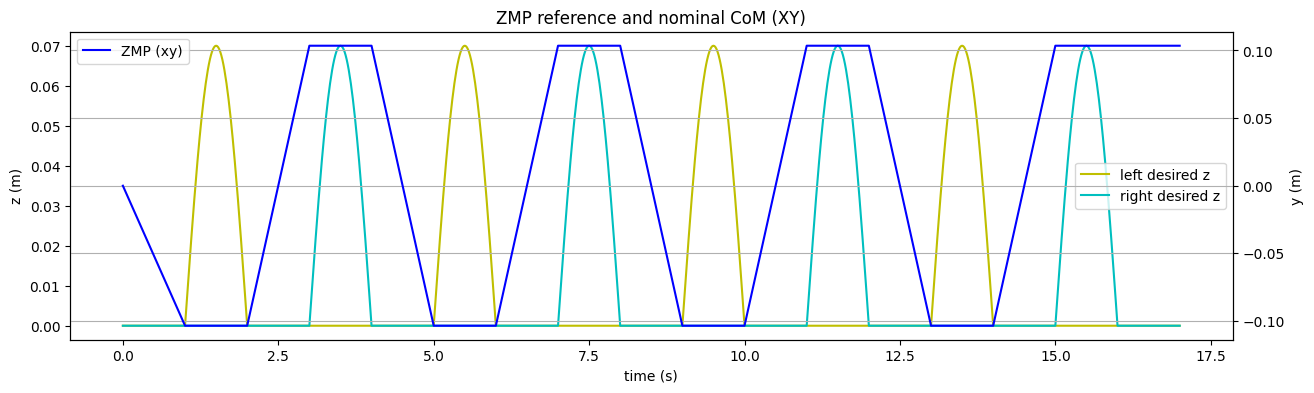

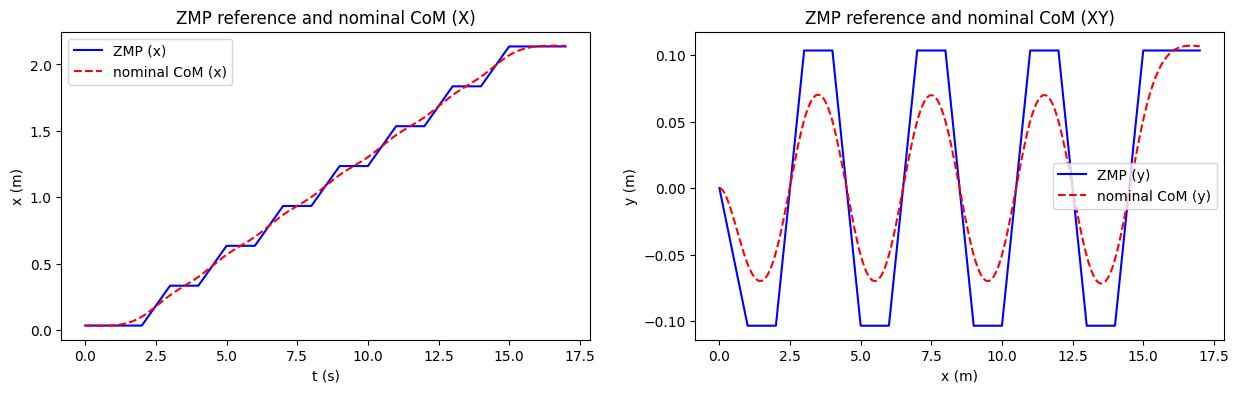

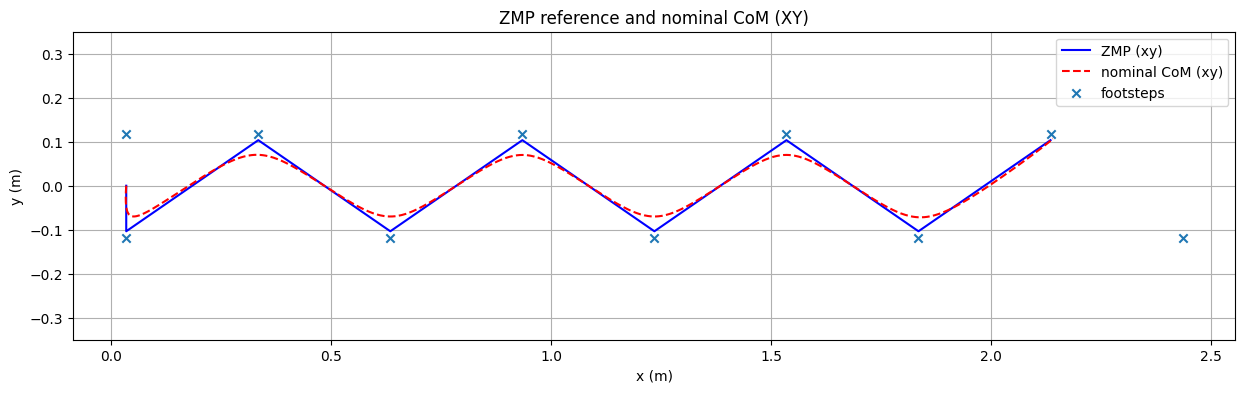

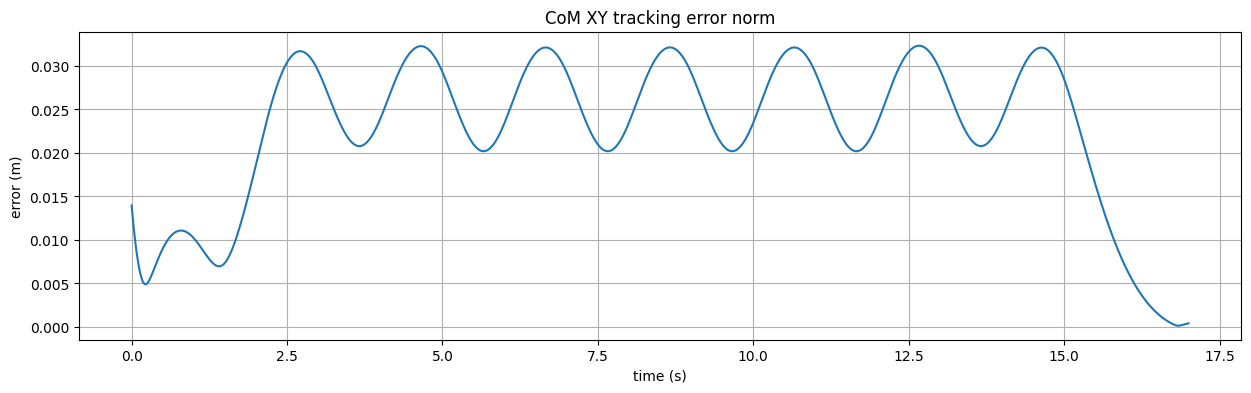

In [12]:
fig, ax1  = plt.subplots(figsize=(15, 4))
ax1.plot(ts, pLz_pair[:,0], 'y', label="left desired z")
# ax1.plot(ts, pLz_pair[:,1], 'r--', label="left actual z")
ax1.plot(ts, pRz_pair[:,0], 'c', label="right desired z")
# ax1.plot(ts, pRz_pair[:,1], 'b--', label="right actual z")
plt.legend()
ax1.set_xlabel("time (s)"); ax1.set_ylabel("z (m)")

ax2 = ax1.twinx()
ax2.plot(ts, zmp_xy[1], 'b',label="ZMP (xy)")
# plt.plot(ts, com_xy[:,1], 'b',label="nominal CoM (xy)")
# plt.scatter(footsteps[:,0], footsteps[:,1], marker="x", label="footsteps")
ax2.grid(True); plt.legend()
plt.title("ZMP reference and nominal CoM (XY)")
plt.xlabel("x (m)"); plt.ylabel("y (m)")
plt.show()

fig, ax  = plt.subplots(1,2,figsize=(15, 4))
ax[0].plot(ts, zmp_xy[0], 'b',label="ZMP (x)")
ax[0].plot(ts, com_xy[:,0], 'r--',label="nominal CoM (x)")
ax[0].legend()
ax[0].set_title("ZMP reference and nominal CoM (X)")
ax[0].set_xlabel("t (s)"); ax[0].set_ylabel("x (m)")
ax[1].plot(ts, zmp_xy[1], 'b',label="ZMP (y)")
ax[1].plot(ts, com_xy[:,1], 'r--',label="nominal CoM (y)")
ax[1].legend()
ax[1].set_title("ZMP reference and nominal CoM (XY)")
ax[1].set_xlabel("x (m)"); ax[1].set_ylabel("y (m)")
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(zmp_xy[0], zmp_xy[1], 'b',label="ZMP (xy)")
plt.plot(com_xy[:,0], com_xy[:,1], 'r--',label="nominal CoM (xy)")
plt.scatter(footsteps[:,0], footsteps[:,1], marker="x", label="footsteps")
plt.axis("equal"); plt.grid(True); plt.legend()
plt.title("ZMP reference and nominal CoM (XY)")
plt.xlabel("x (m)"); plt.ylabel("y (m)")
plt.show()

# CoM XY tracking error (recompute from qpos)
com_cur_xy = []
for q in qpos_traj:
    data.qpos[:] = q
    data.qvel[:] = 0
    mujoco.mj_forward(model, data)
    com_cur_xy.append(data.subtree_com[0][:2].copy())
com_cur_xy = np.array(com_cur_xy)

err = com_cur_xy - com_target_traj[:,:2]
plt.figure(figsize=(15, 4))
plt.plot(ts, np.linalg.norm(err, axis=1))
plt.grid(True)
plt.title("CoM XY tracking error norm")
plt.xlabel("time (s)"); plt.ylabel("error (m)")
plt.show()


## 8. Viewer playback with overlays

We draw overlays using `viewer.user_scn` (capsules for thick lines, spheres for markers).
To keep the code easy to follow, we **clear and redraw overlays every frame**.

If you need to keep other overlays, switch to a pre-allocation scheme.

> **Note:** When drawing with `viewer.user_scn`, it’s best practice to call `mjv_initGeom` to initialize the `mjvGeom` struct **before** calling `mjv_connector`, so that size/rgba/type fields are well-defined for every frame.


In [13]:
def add_line_segment(viewer, p0, p1, width, rgba):
    """Draw a line segment overlay in the MuJoCo viewer (user_scn).

    Note: On many GPU drivers, OpenGL line width is clamped, so this may still
    appear thin even if you increase `width`. (This is why CAPSULE is often used.)
    """
    scn = viewer.user_scn
    if scn.ngeom >= scn.maxgeom:
        return
    g = scn.geoms[scn.ngeom]
    size = np.array([width, 0.0, 0.0], float)
    mujoco.mjv_initGeom(g, mujoco.mjtGeom.mjGEOM_LINE, size,
                        np.zeros(3), np.eye(3).reshape(-1), np.array(rgba, float))
    mujoco.mjv_connector(g, mujoco.mjtGeom.mjGEOM_LINE, width,
                         np.array(p0, float), np.array(p1, float))
    scn.ngeom += 1

def add_sphere(viewer, p, radius, rgba):
    scn = viewer.user_scn
    if scn.ngeom >= scn.maxgeom:
        return
    g = scn.geoms[scn.ngeom]
    size = np.array([radius, 0.0, 0.0], float)
    mujoco.mjv_initGeom(g, mujoco.mjtGeom.mjGEOM_SPHERE, size,
                        np.array(p, float), np.eye(3).reshape(-1), np.array(rgba, float))
    scn.ngeom += 1

def estimate_forward_xy(model, data):
    left_body_id  = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "left_ankle_roll_link")
    right_body_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "right_ankle_roll_link")
    RL = data.xmat[left_body_id].reshape(3,3)
    RR = data.xmat[right_body_id].reshape(3,3)
    f = RL[:,0] + RR[:,0]
    fxy = f[:2]
    n = np.linalg.norm(fxy)
    return (fxy / n) if n > 1e-9 else np.array([1.0, 0.0], float)

def draw_support_parallelogram(viewer, pL, pR, forward_xy, foot_length=0.22, z_lift=0.01,
                               radius=2, rgba=(0,0,1,0.5)):
    f = np.array([forward_xy[0], forward_xy[1], 0.0], float)
    d = 0.5 * foot_length * f
    lift = np.array([0.0, 0.0, z_lift], float)

    Ltoe  = pL + d + lift
    Lheel = pL - d + lift
    Rtoe  = pR + d + lift
    Rheel = pR - d + lift

    corners = [Ltoe, Rtoe, Rheel, Lheel]
    edges = [(0,1), (1,2), (2,3), (3,0)]
    for i,j in edges:
        add_line_segment(viewer, corners[i], corners[j], radius, rgba)


# Precompute task-space trajectories for faster drawing
pL_traj = np.zeros((len(qpos_traj), 3))
pR_traj = np.zeros((len(qpos_traj), 3))
com_traj = np.zeros((len(qpos_traj), 3))
for i, q in enumerate(qpos_traj):
    data.qpos[:] = q
    data.qvel[:] = 0
    mujoco.mj_forward(model, data)
    pL_traj[i] = data.site_xpos[lsole_id]
    pR_traj[i] = data.site_xpos[rsole_id]
    com_traj[i] = data.subtree_com[0]

# Playback
data.qpos[:] = qpos_traj[0]
data.qvel[:] = 0
mujoco.mj_forward(model, data)

TRAIL_LEN = 100
LINE_RADIUS = 2
COM_SPHERE_R = 0.03
FOOT_SPHERE_R = 0.02

with mujoco.viewer.launch_passive(model, data) as viewer:
    start_wall = time.time()

    # -------------------------------------------------------------------------
    # Static overlays: full ZMP reference (at z ~ 0) and desired CoM trajectory
    # These are re-drawn every frame (because we clear user_scn each step).
    # To keep performance reasonable and avoid exceeding maxgeom, we subsample.
    # -------------------------------------------------------------------------
    SHOW_FULL_ZMP = True
    SHOW_FULL_COM_DES = True
    ZMP_Z = 0.015  # lift a bit above the floor to avoid z-fighting

    # Budget user_scn geoms:
    #   - dynamic trails: ~3*(TRAIL_LEN-1) lines + 3 spheres + 4 DS edges
    #   - static full paths: 2*(N_FULL-1) lines (ZMP + desired CoM)
    maxgeom = int(viewer.user_scn.maxgeom)
    dyn_budget = 3 * (TRAIL_LEN - 1) + 3 + 4
    full_budget_lines = max(40, maxgeom - dyn_budget - 20)     # leave margin
    N_FULL = int(np.clip(full_budget_lines // 2 + 1, 30, 350)) # 2 polylines

    # Time span matches the generated qpos trajectory
    T_total = float(DT * (len(qpos_traj) - 1))
    ts_full = np.linspace(0.0, T_total, N_FULL)

    # Precompute 3D points for polylines
    zmp_path = np.zeros((N_FULL, 3))
    com_des_path = np.zeros((N_FULL, 3))

    # Clamp evaluation times into Drake traj domain (safety)
    t0_zmp = float(zmp_traj.start_time())
    tf_zmp = float(zmp_traj.end_time())

    for k, t in enumerate(ts_full):
        te = float(np.clip(t, t0_zmp, tf_zmp))
        zxy = np.asarray(zmp_traj.value(te)).reshape(2)
        cxy = np.asarray(zmp_planner.get_nominal_com(te)).reshape(2)
        zmp_path[k, :2] = zxy
        zmp_path[k, 2] = ZMP_Z
        com_des_path[k, :2] = cxy
        com_des_path[k, 2] = float(com_z_ref)

    while viewer.is_running():
        wall_t = time.time() - start_wall
        i = int(wall_t / DT) % len(qpos_traj)

        data.qpos[:] = qpos_traj[i]
        data.qvel[:] = 0
        mujoco.mj_forward(model, data)

        # clear overlays
        viewer.user_scn.ngeom = 0


        # full planned trajectories (static, re-drawn each frame)
        if SHOW_FULL_ZMP:
            for k in range(1, N_FULL):
                add_line_segment(viewer, zmp_path[k-1], zmp_path[k], LINE_RADIUS, (0, 1, 0, 0.8))
        if SHOW_FULL_COM_DES:
            for k in range(1, N_FULL):
                add_line_segment(viewer, com_des_path[k-1], com_des_path[k], LINE_RADIUS, (1, 1, 1, 0.8))


        # trails
        j0 = max(0, i-TRAIL_LEN)
        for k in range(j0+1, i+1):
            add_line_segment(viewer, pL_traj[k-1], pL_traj[k], LINE_RADIUS, (1,1,0,0.6))
            add_line_segment(viewer, pR_traj[k-1], pR_traj[k], LINE_RADIUS, (0,1,1,0.6))
            add_line_segment(viewer, com_traj[k-1], com_traj[k], LINE_RADIUS, (1,0,0,0.5))

        # current markers
        add_sphere(viewer, pL_traj[i], FOOT_SPHERE_R, (1,1,0,1))
        add_sphere(viewer, pR_traj[i], FOOT_SPHERE_R, (0,1,1,1))
        add_sphere(viewer, com_traj[i], COM_SPHERE_R, (1,0,0,1))

        # DS support polygon
        phase, step_i, swing_left, s = phase_and_progress(float(i*DT), ds, ss, len(footsteps))
        if phase == "DS":
            fxy = estimate_forward_xy(model, data)
            draw_support_parallelogram(viewer, pL_traj[i], pR_traj[i], fxy)

        viewer.sync()


In [14]:
# ----------------------------
# Physics playback (mj_step) + logs
# ----------------------------
import numpy as np
import time
import mujoco
import mujoco.viewer
import matplotlib.pyplot as plt

# ---- prerequisites: you need actuators to apply controls
if model.nu == 0:
    raise RuntimeError(
        "This model has model.nu == 0 (no actuators). "
        "To run physics tracking, add torque/position actuators in the MJCF."
    )

# ---- helper: safe name lookup
def _name(objtype, objid):
    s = mujoco.mj_id2name(model, objtype, objid)
    return s if s is not None else ""

# ---- find a 'floor' geom (used for ZMP estimation)
floor_gid = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_GEOM, "floor")
if floor_gid < 0:
    # fallback: first plane geom
    floor_gid = -1
    for gid in range(model.ngeom):
        if model.geom_type[gid] == mujoco.mjtGeom.mjGEOM_PLANE:
            floor_gid = gid
            break
if floor_gid < 0:
    raise RuntimeError("Could not find a floor geom (name='floor' or any plane geom).")

floor_name = _name(mujoco.mjtObj.mjOBJ_GEOM, floor_gid)
print("[DEBUG] floor geom:", floor_name, "id=", floor_gid)

# ---- map actuators -> joints -> qpos/qvel indices
act_joint_id = model.actuator_trnid[:, 0].copy()            # (nu,)
act_qpos_adr = model.jnt_qposadr[act_joint_id].copy()       # index into qpos
act_dof_adr  = model.jnt_dofadr[act_joint_id].copy()        # index into qvel (nv)

act_joint_names = [_name(mujoco.mjtObj.mjOBJ_JOINT, int(jid)) for jid in act_joint_id]

# ---- decide which actuators are "legs" vs "upper body"
# We keep "upper body joints fixed" by setting their gains to 0 in the tracker.
UPPER_KEYWORDS = ["shoulder", "elbow", "wrist", "neck", "head", "arm", "hand"]
leg_mask = np.ones(model.nu, dtype=bool)
for i, jn in enumerate(act_joint_names):
    jnl = jn.lower()
    if any(k in jnl for k in UPPER_KEYWORDS):
        leg_mask[i] = False

print(f"[DEBUG] actuators total: {model.nu}, leg-driven: {int(np.sum(leg_mask))}")

# ---- PD gains (tune if needed)
KP = np.zeros(model.nu)
KD = np.zeros(model.nu)

# Legs track more aggressively (walking)
KP[leg_mask] = 400.0
KD[leg_mask] = 12.0

# Upper body holds the initial posture (so arms/head don't collapse)
KP[~leg_mask] = 80.0
KD[~leg_mask] = 6.0

# Optional: clip to actuator ctrlrange if present
has_ctrlrange = (model.actuator_ctrllimited is not None) and np.any(model.actuator_ctrllimited)

def clip_ctrl(u):
    if not has_ctrlrange:
        return u
    lo = model.actuator_ctrlrange[:, 0]
    hi = model.actuator_ctrlrange[:, 1]
    return np.minimum(np.maximum(u, lo), hi)

# ---- interpolate reference joint angles from qpos_traj
Nref = len(qpos_traj)
T_total = float(DT * (Nref - 1))

# Keep a copy of the initial actuator posture for holding the upper body
q_hold_act = qpos_traj[0][act_qpos_adr].copy()

# ---- hold a quiet standing period before walking (seconds)
T_STAND = 3
# Optional: smoothly ramp controller gains at the very beginning (0 disables)
GAIN_RAMP = 0.0

def ref_at_time(t):
    """Return (qref, qdref) for actuated joints at time t.

    - For t in [0, T_STAND): hold the initial configuration (standing check).
    - After that: track the wrapped walking reference qpos_traj.
    """
    t = float(t)
    if t < T_STAND:
        qref = q_hold_act.copy()
        qdref = np.zeros_like(qref)
        return qref, qdref

    tw = float((t - T_STAND) % T_total)
    i0 = int(np.floor(tw / DT))
    a = (tw - i0 * DT) / DT
    i1 = (i0 + 1) % Nref

    q0 = qpos_traj[i0]
    q1 = qpos_traj[i1]

    qref = (1 - a) * q0[act_qpos_adr] + a * q1[act_qpos_adr]
    qdref = (q1[act_qpos_adr] - q0[act_qpos_adr]) / DT

    # Hold upper body at the initial posture (prevents arms/head from collapsing)
    qref[~leg_mask] = q_hold_act[~leg_mask]
    qdref[~leg_mask] = 0.0

    return qref, qdref

# ---- estimate ZMP from contacts with the floor
def estimate_zmp_from_contacts(model, data, floor_gid):
    F = np.zeros(3)
    M = np.zeros(3)
    f6 = np.zeros(6)

    for ci in range(data.ncon):
        con = data.contact[ci]
        g1 = int(con.geom1)
        g2 = int(con.geom2)

        # only contacts between floor and non-floor
        if not ((g1 == floor_gid) ^ (g2 == floor_gid)):
            continue

        mujoco.mj_contactForce(model, data, ci, f6)

        # contact frame -> world
        R = np.array(con.frame).reshape(3, 3)
        f_world = R @ f6[:3]
        p_world = np.array(con.pos)

        # mj_contactForce returns force on geom1.
        # We want the force ON THE ROBOT from the floor.
        sign = -1.0 if g1 == floor_gid else 1.0
        f_world = sign * f_world

        F += f_world
        M += np.cross(p_world, f_world)

    if F[2] < 1e-6:
        return None, F, M

    # ZMP on ground z=0:
    zmp = np.array([-M[1] / F[2], M[0] / F[2], 0.0])
    return zmp, F, M

# ---- prepare a fresh sim data
data_sim = mujoco.MjData(model)
data_sim.qpos[:] = qpos_traj[0]
data_sim.qvel[:] = 0
mujoco.mj_forward(model, data_sim)

# ---- static polylines for full planned ZMP + desired CoM
def precompute_polyline(zmp_traj, zmp_planner, com_z_ref, ZMP_Z, N=250):
    ts = np.linspace(0.0, T_total, N)
    z_path = np.zeros((N, 3))
    c_path = np.zeros((N, 3))
    t0 = float(zmp_traj.start_time())
    tf = float(zmp_traj.end_time())
    for k, t in enumerate(ts):
        te = float(np.clip(t, t0, tf))
        zxy = np.asarray(zmp_traj.value(te)).reshape(2)
        cxy = np.asarray(zmp_planner.get_nominal_com(te)).reshape(2)
        z_path[k, :2] = zxy
        z_path[k, 2] = ZMP_Z
        c_path[k, :2] = cxy
        c_path[k, 2] = float(com_z_ref)
    return ts, z_path, c_path

ZMP_Z = globals().get("ZMP_Z", 0.015)
LINE_RADIUS = globals().get("LINE_RADIUS", 0.01)
COM_SPHERE_R  = globals().get("COM_SPHERE_R", 0.03)

ts_full, zmp_path, com_des_path = precompute_polyline(zmp_traj, zmp_planner, com_z_ref, ZMP_Z, N=250)

# ---- overlay primitives (LINE + SPHERE)
def add_line_segment(viewer, p0, p1, width, rgba):
    scn = viewer.user_scn
    if scn.ngeom >= scn.maxgeom:
        return
    g = scn.geoms[scn.ngeom]
    size = np.array([width, 0.0, 0.0], float)
    mujoco.mjv_initGeom(g, mujoco.mjtGeom.mjGEOM_LINE, size,
                        np.zeros(3), np.eye(3).reshape(-1), np.array(rgba, float))
    mujoco.mjv_connector(g, mujoco.mjtGeom.mjGEOM_LINE, width,
                         np.array(p0, float), np.array(p1, float))
    scn.ngeom += 1

def add_sphere(viewer, pos, radius, rgba):
    scn = viewer.user_scn
    if scn.ngeom >= scn.maxgeom:
        return
    g = scn.geoms[scn.ngeom]
    size = np.array([radius, 0.0, 0.0], float)
    mujoco.mjv_initGeom(g, mujoco.mjtGeom.mjGEOM_SPHERE, size,
                        np.array(pos, float), np.eye(3).reshape(-1), np.array(rgba, float))
    scn.ngeom += 1

# ---- logs
log_t = []
log_com = []
log_com_des = []
log_zmp = []
log_zmp_des = []
log_Fz = []
log_force_res = []

mass = float(np.sum(model.body_mass[1:]))
gvec = np.array(model.opt.gravity, float)

prev_com = data_sim.subtree_com[0].copy()
prev_com_vel = np.zeros(3)

SIM_DT = float(model.opt.timestep)
SUBSTEPS = int(max(1, np.round(DT / SIM_DT)))

print("[DEBUG] SIM_DT =", SIM_DT, "SUBSTEPS/frame =", SUBSTEPS, "ref DT =", DT)
print("[DEBUG] Stand check period T_STAND =", T_STAND, "s (hold qpos_traj[0])")

with mujoco.viewer.launch_passive(model, data_sim) as viewer:
    while viewer.is_running():
        # integrate physics for SUBSTEPS
        for _ in range(SUBSTEPS):
            # Make sure bias forces (gravity + Coriolis) are up to date
            mujoco.mj_forward(model, data_sim)

            qref, qdref = ref_at_time(data_sim.time)

            qcur = data_sim.qpos[act_qpos_adr]
            qdcur = data_sim.qvel[act_dof_adr]

            gain_scale = 1.0 if GAIN_RAMP <= 0 else float(np.clip(data_sim.time / GAIN_RAMP, 0.0, 1.0))

            # PD tracking term (optionally ramped)
            u_pd = gain_scale * (KP * (qref - qcur) + KD * (qdref - qdcur))

            # Feed-forward gravity/Coriolis compensation (torque motors with default gear=1)
            u_ff = data_sim.qfrc_bias[act_dof_adr].copy()

            u = u_ff + u_pd
            u = clip_ctrl(u)
            print

            data_sim.ctrl[:] = u
            mujoco.mj_step(model, data_sim)

        ank_idx = [i for i,n in enumerate(act_joint_names) if "ankle_pitch_joint" in n]
        # inside sim loop, every ~50 steps:
        print("t", data_sim.time,
            "ank_q",  data_sim.qpos[act_qpos_adr[ank_idx]],
            "ank_ref", qref[ank_idx],
            "ctrl", data_sim.ctrl[ank_idx])
    
        # desired ZMP / CoM at current (wrapped) time
        # print('data_sim.time - T_STAND=', data_sim.time - T_STAND)
        # if (data_sim.time - T_STAND) > -0:
        #     print('Time up')
        #     break
        t_plan = float(max(0.0, data_sim.time - T_STAND))
        tw = float(t_plan % T_total)
        te = float(np.clip(tw, float(zmp_traj.start_time()), float(zmp_traj.end_time())))
        zxy_des = np.asarray(zmp_traj.value(te)).reshape(2)
        cxy_des = np.asarray(zmp_planner.get_nominal_com(te)).reshape(2)

        zmp_des = np.array([zxy_des[0], zxy_des[1], 0.0])
        com_des = np.array([cxy_des[0], cxy_des[1], float(com_z_ref)])

        # measure actual CoM and ZMP
        com = data_sim.subtree_com[0].copy()
        zmp_meas, F, M = estimate_zmp_from_contacts(model, data_sim, floor_gid)
        if zmp_meas is None:
            zmp_meas = np.array([np.nan, np.nan, 0.0])

        # numerical com acceleration (at visual rate)
        com_vel = (com - prev_com) / (SUBSTEPS * SIM_DT)
        com_acc = (com_vel - prev_com_vel) / (SUBSTEPS * SIM_DT)
        prev_com = com.copy()
        prev_com_vel = com_vel.copy()

        # centroidal force balance residual
        resF = mass * com_acc - (F + mass * gvec)
        res_norm = float(np.linalg.norm(resF))

        # log
        log_t.append(float(data_sim.time))
        log_com.append(com)
        log_com_des.append(com_des)
        log_zmp.append(np.array([zmp_meas[0], zmp_meas[1], 0.0]))
        log_zmp_des.append(zmp_des)
        log_Fz.append(float(F[2]))
        log_force_res.append(res_norm)

        # draw overlays (keep full planned trajectories visible)
        viewer.user_scn.ngeom = 0

        for k in range(1, len(zmp_path)):
            add_line_segment(viewer, zmp_path[k-1], zmp_path[k], LINE_RADIUS, (0,1,0,0.6))

        for k in range(1, len(com_des_path)):
            add_line_segment(viewer, com_des_path[k-1], com_des_path[k], LINE_RADIUS, (1,0,0,0.4))

        add_sphere(viewer, com, COM_SPHERE_R, (1,0,0,1))                       # actual CoM (red)
        add_sphere(viewer, com_des, COM_SPHERE_R*0.8, (1,0.6,0.6,1))           # desired CoM
        add_sphere(viewer, np.array([zmp_des[0], zmp_des[1], ZMP_Z]), 0.02, (0,1,0,1))     # desired ZMP
        if np.isfinite(zmp_meas[0]):
            add_sphere(viewer, np.array([zmp_meas[0], zmp_meas[1], ZMP_Z]), 0.02, (0,0,1,1)) # measured ZMP

        viewer.sync()
        # time.sleep(0.1)

# to arrays
log_t = np.array(log_t)
log_com = np.asarray(log_com)
log_com_des = np.asarray(log_com_des)
log_zmp = np.asarray(log_zmp)
log_zmp_des = np.asarray(log_zmp_des)
log_Fz = np.asarray(log_Fz)
log_force_res = np.asarray(log_force_res)

print("[DEBUG] logged frames:", len(log_t))

[DEBUG] floor geom: floor id= 0
[DEBUG] actuators total: 29, leg-driven: 15
[DEBUG] SIM_DT = 0.002 SUBSTEPS/frame = 8 ref DT = 0.016666666666666666
[DEBUG] Stand check period T_STAND = 3 s (hold qpos_traj[0])
t 0.016 ank_q [-0.0058 -0.0057] ank_ref [-0.0054 -0.0052] ctrl [0.4617 0.4592]
t 0.032000000000000015 ank_q [-0.0061 -0.006 ] ank_ref [-0.0054 -0.0052] ctrl [0.1973 0.1949]
t 0.04800000000000003 ank_q [-0.0059 -0.0058] ank_ref [-0.0054 -0.0052] ctrl [-0.0824 -0.0848]
t 0.06400000000000004 ank_q [-0.0057 -0.0056] ank_ref [-0.0054 -0.0052] ctrl [-0.1309 -0.1333]
t 0.08000000000000006 ank_q [-0.0057 -0.0055] ank_ref [-0.0054 -0.0052] ctrl [-0.0552 -0.0576]
t 0.09600000000000007 ank_q [-0.0058 -0.0056] ank_ref [-0.0054 -0.0052] ctrl [0.0928 0.0904]
t 0.11200000000000009 ank_q [-0.006  -0.0059] ank_ref [-0.0054 -0.0052] ctrl [0.2975 0.295 ]
t 0.12800000000000009 ank_q [-0.0064 -0.0062] ank_ref [-0.0054 -0.0052] ctrl [0.5447 0.5422]
t 0.1440000000000001 ank_q [-0.0069 -0.0067] ank_ref [